### Visualize data in a netCDF file

In [1]:
%matplotlib ipympl
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
#datafile = '/mnt/c/Users/clmbn/NMT_PhD/data/MODSCAG/WUS_Snow_Daily_2008_MODSCAG.nc'
#datafile = '/mnt/c/Users/clmbn/NMT_PhD/data/SWANN/SWE_UA_regridded_v2/4km_SWE_Depth_WY2002_v01_0.125deg_WUS.nc'
#datafile = '/mnt/c/Users/clmbn/NMT_PhD/data/SWANN/UA_NSIDC/grid_0125deg/0125deg_SWE_Depth_WY2009_v01_B.nc'
datafile = '/mnt/c/Users/clmbn/NMT_PhD/data/E3SM/fSCA/offline_calcs/fsca_helbig_0125deg_test0416.nc'
#datafile = '/home/chriscox/Desktop/coding/netcdf_tools/tests/spires_regridded_test.nc'

In [3]:
ds = xr.open_dataset(datafile)
print(ds)

<xarray.Dataset> Size: 71MB
Dimensions:  (time: 730, lat: 144, lon: 168)
Coordinates:
  * time     (time) datetime64[ns] 6kB 2008-10-01 2008-10-02 ... 2010-09-30
  * lat      (lat) float32 576B 49.94 49.81 49.69 49.56 ... 32.31 32.19 32.06
  * lon      (lon) float32 672B -124.9 -124.8 -124.7 ... -104.3 -104.2 -104.1
Data variables:
    fSCA     (time, lat, lon) float32 71MB ...


In [4]:
# Configure plot: specify variable name and time
plot_var = 'fSCA'
plot_time = '2009-02-01'  # date string or integer index

# Domain limits (set to None to show full extent)
lat_min = None
lat_max = None
lon_min = None
lon_max = None

var = ds[plot_var]
print(var)

<xarray.DataArray 'fSCA' (time: 730, lat: 144, lon: 168)> Size: 71MB
[17660160 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 6kB 2008-10-01 2008-10-02 ... 2010-09-30
  * lat      (lat) float32 576B 49.94 49.81 49.69 49.56 ... 32.31 32.19 32.06
  * lon      (lon) float32 672B -124.9 -124.8 -124.7 ... -104.3 -104.2 -104.1
Attributes:
    long_name:      Fractional Snow Cover Area (fSCA_helbig)
    valid_range:    [0. 1.]
    domain_size_m:  12500.0


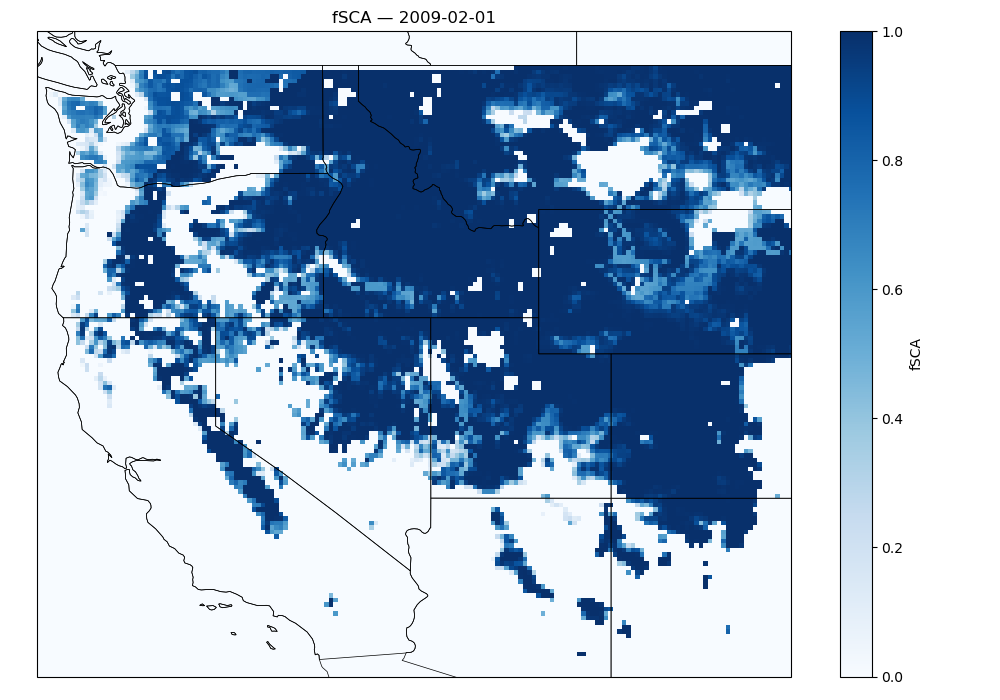

In [5]:
# WUS Plot
# Select time by date string or integer index
if isinstance(plot_time, int):
    data_t = var.isel(time=plot_time)
    time_label = str(var.time.values[plot_time])[:10]
else:
    data_t = var.sel(time=plot_time, method='nearest')
    time_label = str(data_t.time.values)[:10]

fig, ax = plt.subplots(
    subplot_kw={'projection': ccrs.PlateCarree()},
    figsize=(10, 7)
)

cmap = plt.get_cmap('Blues').copy()
cmap.set_bad('red')

img = ax.pcolormesh(
    ds['lon'], ds['lat'], data_t,
    transform=ccrs.PlateCarree(),
    cmap=cmap
)

# Apply domain limits if set
_lon_min = lon_min if lon_min is not None else float(ds['lon'].min())
_lon_max = lon_max if lon_max is not None else float(ds['lon'].max())
_lat_min = lat_min if lat_min is not None else float(ds['lat'].min())
_lat_max = lat_max if lat_max is not None else float(ds['lat'].max())
ax.set_extent([_lon_min, _lon_max, _lat_min, _lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='black')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

plt.colorbar(img, ax=ax, label=var.attrs.get('units', plot_var))
ax.set_title(f'{plot_var} — {time_label}')
plt.tight_layout()
plt.show()

In [7]:
# Zoomed plot config — set center and half-width of view
center_lat = 35.7
center_lon = -105.8  # -180 to 180 convention
span = 2           # degrees in each direction from center

lon_0_360 = False     # Set True if the dataset uses 0–360 longitude convention

In [8]:
import numpy as np
import cartopy.io.shapereader as shpreader

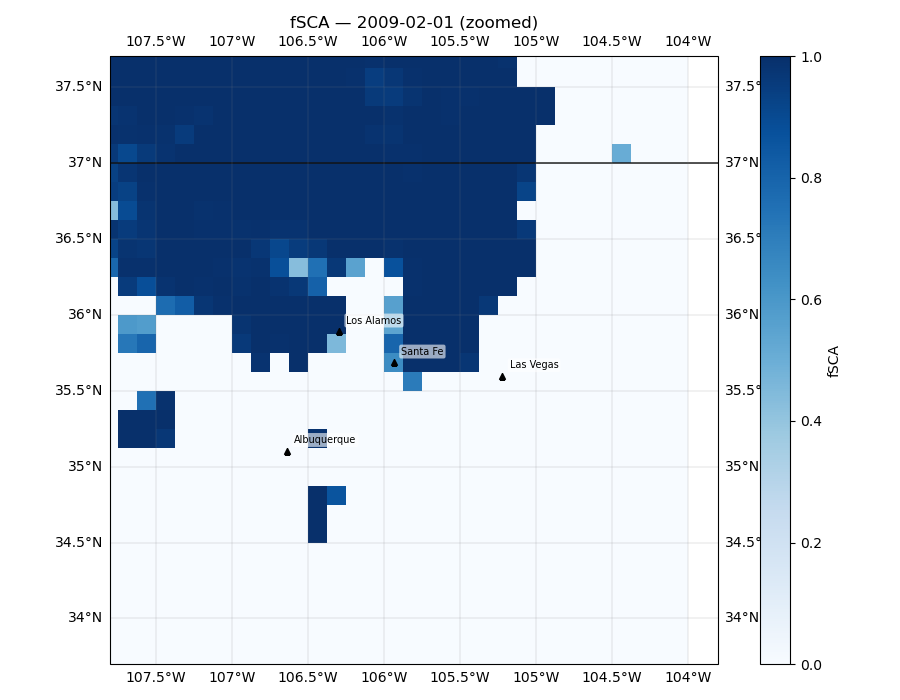

In [9]:
if isinstance(plot_time, int):
    data_t = var.isel(time=plot_time)
    time_label = str(var.time.values[plot_time])[:10]
else:
    data_t = var.sel(time=plot_time, method='nearest')
    time_label = str(data_t.time.values)[:10]

# Extent in -180:180 convention
extent = [
    center_lon - span, center_lon + span,
    center_lat - span, center_lat + span,
]

# Compute vmax from data within the zoomed domain
lon_sel = ds['lon'].values
lat_sel = ds['lat'].values
if lon_0_360:
    lon_min_sel = extent[0] + 360 if extent[0] < 0 else extent[0]
    lon_max_sel = extent[1] + 360 if extent[1] < 0 else extent[1]
else:
    lon_min_sel, lon_max_sel = extent[0], extent[1]
lat_mask = (lat_sel >= extent[2]) & (lat_sel <= extent[3])
lon_mask = (lon_sel >= lon_min_sel) & (lon_sel <= lon_max_sel)
zoomed_data = data_t.values[np.ix_(lat_mask, lon_mask)]
vmax = float(np.nanmax(zoomed_data))

fig, ax = plt.subplots(
    subplot_kw={'projection': ccrs.PlateCarree()},
    figsize=(9, 7)
)

img = ax.pcolormesh(
    ds['lon'], ds['lat'], data_t,
    transform=ccrs.PlateCarree(),
    cmap='Blues',
    vmax=vmax
)

ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='black')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)

plt.colorbar(img, ax=ax, label=var.attrs.get('units', plot_var))
ax.set_title(f'{plot_var} — {time_label} (zoomed)')

# Add populated places with population >= threshold
pop_threshold = 10_000
shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='populated_places')
reader = shpreader.Reader(shpfilename)
lon_min_ext, lon_max_ext, lat_min_ext, lat_max_ext = extent
for record in reader.records():
    pop = record.attributes['POP_MAX']
    city_lon = record.geometry.x  # natural earth uses -180:180
    city_lat = record.geometry.y
    if pop >= pop_threshold and lon_min_ext <= city_lon <= lon_max_ext and lat_min_ext <= city_lat <= lat_max_ext:
        ax.plot(city_lon, city_lat, 'k^', markersize=5, transform=ccrs.PlateCarree())
        ax.text(city_lon + 0.05, city_lat + 0.05,
                record.attributes['NAME'],
                fontsize=7, transform=ccrs.PlateCarree(),
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

# Hover tooltip: show lat/lon and value under cursor
lon_vals = ds['lon'].values
lat_vals = ds['lat'].values
data_np = data_t.values

annot = ax.annotate('', xy=(0, 0), xytext=(8, 8),
                    textcoords='offset points',
                    bbox=dict(boxstyle='round', fc='white', alpha=0.8),
                    fontsize=8)
annot.set_visible(False)

def on_move(event):
    if event.inaxes != ax:
        annot.set_visible(False)
        fig.canvas.draw_idle()
        return
    lon_click, lat_click = event.xdata, event.ydata
    if lon_click is None or lat_click is None:
        return
    # Convert to dataset's longitude convention for array lookup
    lon_lookup = lon_click + 360 if (lon_0_360 and lon_click < 0) else lon_click
    i = np.argmin(np.abs(lat_vals - lat_click))
    j = np.argmin(np.abs(lon_vals - lon_lookup))
    val = data_np[i, j]
    annot.xy = (event.xdata, lat_click)
    annot.set_text(f'lat={lat_vals[i]:.3f}\nlon={lon_click:.3f}\n{plot_var}={val:.4f}')
    annot.set_visible(True)
    fig.canvas.draw_idle()

fig.canvas.mpl_connect('motion_notify_event', on_move)
plt.tight_layout()
plt.show()

In [10]:
plt.close('all')